# 🎓 Student Dropout — Phase 3: Model Training (Binary Recall-Maximization Pipeline)

**Input:** `../data/processed/processed_dataset.csv`  
**Output:** `../models/xgboost_dropout_model.pkl`, `../models/best_model.pkl`, `../models/model_metadata.pkl`

**Pipeline:**
1. Imports & Config
2. Data Loading & Feature Preparation
3. Label Propagation — Enrolled students assigned soft pseudo-labels via KNN
4. HPO Pipeline — RandomizedSearchCV with SMOTE inside CV folds, optimizing Dropout recall
5. Threshold Optimization — scan 0.1–0.9 to achieve ≥90% Dropout recall
6. Final Training & Export — retrain best model on full labeled + pseudo-labeled set

## 1. Imports & Config

All dependencies are imported here. `RANDOM_STATE` and `ENROLLED_PSEUDO_THRESHOLD` are the two global constants used throughout the pipeline.

In [9]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    make_scorer, recall_score, precision_score, f1_score, accuracy_score
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [10]:
# ── Global Configuration ──────────────────────────────────────────────────────
RANDOM_STATE = 42
ENROLLED_PSEUDO_THRESHOLD = 0.6

print(f'RANDOM_STATE             = {RANDOM_STATE}')
print(f'ENROLLED_PSEUDO_THRESHOLD = {ENROLLED_PSEUDO_THRESHOLD}')

RANDOM_STATE             = 42
ENROLLED_PSEUDO_THRESHOLD = 0.6


## 2. Data Loading & Feature Preparation

- Drop target columns (`Target`, `Target_Encoded`, `Target_Binary`) from the feature matrix.
- Drop unscaled counterparts of continuous columns to avoid duplication — use `_scaled` versions instead.
- Split into a hard-labeled set (Dropout / Graduate) and an Enrolled set for label propagation.

In [11]:
df = pd.read_csv('../data/processed/processed_dataset.csv')
print(f'Loaded dataset: {df.shape}')

# Columns that have a _scaled version — drop the raw originals
UNSCALED_TO_DROP = [
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate',
    'Inflation rate',
    'GDP',
    'semester_performance_delta'
]

TARGET_COLS = ['Target', 'Target_Encoded', 'Target_Binary']

X = df.drop(columns=TARGET_COLS + UNSCALED_TO_DROP)

print(f'Feature matrix shape: {X.shape}')
print(f'Features ({len(X.columns)}):', X.columns.tolist())

# Split: hard-labeled (Dropout / Graduate) vs. Enrolled
labeled_mask  = df['Target_Binary'].notna()
enrolled_mask = df['Target'] == 'Enrolled'

X_labeled  = X[labeled_mask].reset_index(drop=True)
y_labeled  = df.loc[labeled_mask, 'Target_Binary'].astype(int).reset_index(drop=True)
X_enrolled = X[enrolled_mask].reset_index(drop=True)

print(f'\nLabeled set shape  : {X_labeled.shape}')
print('Class distribution (labeled):')
print(y_labeled.value_counts().rename({0: 'Graduate (0)', 1: 'Dropout (1)'}).to_string())
print(f'\nEnrolled set shape : {X_enrolled.shape}')

Loaded dataset: (4424, 49)
Feature matrix shape: (4424, 39)
Features (39): ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (without evaluations)', 'zero_approved_units_flag', 'financial_stress_flag', 'engagement_ratio_1st_sem', 'engagement_ratio_2nd_sem', 'Age at enrollment_scaled', 'Cu

## 3. Label Propagation

Enrolled students have an unknown final outcome. A KNN classifier (n=15, distance-weighted) is fit on the hard-labeled set and used to assign soft probability scores to Enrolled students. Those with a class probability above `ENROLLED_PSEUDO_THRESHOLD` are promoted into the training set as pseudo-labeled samples with a sample weight equal to the propagated probability.

In [12]:
# ── 3. Label Propagation ──────────────────────────────────────────────────────
# Fit KNN on hard-labeled set, propagate probabilities to Enrolled students,
# and promote high-confidence predictions as pseudo-labeled training samples.

knn = KNeighborsClassifier(n_neighbors=15, weights='distance')
knn.fit(X_labeled, y_labeled)

# predict_proba returns columns in order of knn.classes_
# knn.classes_ = [0, 1]  →  index 0 = Graduate (0), index 1 = Dropout (1)
proba_enrolled = knn.predict_proba(X_enrolled)

# Guard: raise if any probability is NaN
if np.isnan(proba_enrolled).any():
    raise ValueError(
        'Label propagation produced NaN probabilities. '
        'Check X_enrolled for missing or infinite values.'
    )

p_graduate = proba_enrolled[:, 0]
p_dropout  = proba_enrolled[:, 1]

pseudo_indices_dropout  = []
pseudo_indices_graduate = []
pseudo_indices_ambiguous = []

for i in range(len(X_enrolled)):
    if p_dropout[i] > ENROLLED_PSEUDO_THRESHOLD:
        pseudo_indices_dropout.append(i)
    elif p_graduate[i] > ENROLLED_PSEUDO_THRESHOLD:
        pseudo_indices_graduate.append(i)
    else:
        pseudo_indices_ambiguous.append(i)

n_pseudo_dropout  = len(pseudo_indices_dropout)
n_pseudo_graduate = len(pseudo_indices_graduate)
n_ambiguous       = len(pseudo_indices_ambiguous)

print(f'Pseudo-labeled Dropout  : {n_pseudo_dropout}')
print(f'Pseudo-labeled Graduate : {n_pseudo_graduate}')
print(f'Ambiguous (excluded)    : {n_ambiguous}')
print(f'Total Enrolled          : {len(X_enrolled)}')

# Build pseudo-labeled arrays
all_pseudo_indices = pseudo_indices_dropout + pseudo_indices_graduate

if len(all_pseudo_indices) == 0:
    # Edge case: all Enrolled students are ambiguous — proceed with labeled set only
    import warnings as _warnings
    _warnings.warn(
        'All Enrolled students are ambiguous (none promoted). '
        'Proceeding with hard-labeled set only.',
        UserWarning
    )
    X_train_aug = X_labeled
    y_train_aug = y_labeled
    w_train_aug = np.ones(len(X_labeled))
else:
    X_pseudo_dropout  = X_enrolled.iloc[pseudo_indices_dropout]
    y_pseudo_dropout  = pd.Series([1] * n_pseudo_dropout, dtype=int)
    w_pseudo_dropout  = p_dropout[pseudo_indices_dropout]

    X_pseudo_graduate  = X_enrolled.iloc[pseudo_indices_graduate]
    y_pseudo_graduate  = pd.Series([0] * n_pseudo_graduate, dtype=int)
    w_pseudo_graduate  = p_graduate[pseudo_indices_graduate]

    X_pseudo = pd.concat([X_pseudo_dropout, X_pseudo_graduate], ignore_index=True)
    y_pseudo = pd.concat([y_pseudo_dropout, y_pseudo_graduate], ignore_index=True)
    w_pseudo = np.concatenate([w_pseudo_dropout, w_pseudo_graduate])

    # Augmented training set: hard-labeled + pseudo-labeled
    X_train_aug = pd.concat([X_labeled, X_pseudo], ignore_index=True)
    y_train_aug = pd.concat([y_labeled, y_pseudo], ignore_index=True)
    w_train_aug = np.concatenate([np.ones(len(X_labeled)), w_pseudo])

print(f'\nAugmented training set shape : {X_train_aug.shape}')
print('Class distribution (augmented):')
print(y_train_aug.value_counts().rename({0: 'Graduate (0)', 1: 'Dropout (1)'}).to_string())

Pseudo-labeled Dropout  : 110
Pseudo-labeled Graduate : 520
Ambiguous (excluded)    : 164
Total Enrolled          : 794

Augmented training set shape : (4260, 39)
Class distribution (augmented):
Graduate (0)    2729
Dropout (1)     1531


## 4. HPO Pipeline (Optuna)

For each of three model families (Logistic Regression, Random Forest, XGBoost), an `imblearn.pipeline.Pipeline` wraps SMOTE followed by the classifier. An **Optuna** study (TPE sampler, 100 trials, 5-fold stratified CV) optimizes for mean Dropout recall (`pos_label=1`). SMOTE is applied only inside each fold to prevent data leakage. XGBoost trials additionally use `MedianPruner` to kill unpromising configurations early.


── Logistic Regression ──────────────────────────────────────────────


  0%|          | 0/100 [00:00<?, ?it/s]

  Best params  : {'C': 0.004366542580474673, 'solver': 'lbfgs', 'class_weight': None}
  Best recall  : 0.8432
  Recall       : 0.8432 ± 0.0135
  Precision    : 0.8218 ± 0.0087
  F1-macro     : 0.8682 ± 0.0077
  Accuracy     : 0.8779 ± 0.0070

── Random Forest ──────────────────────────────────────────────


  0%|          | 0/100 [00:00<?, ?it/s]

  Best params  : {'n_estimators': 137, 'max_depth': 20, 'min_samples_split': 15, 'class_weight': 'balanced'}
  Best recall  : 0.8236
  Recall       : 0.8236 ± 0.0139
  Precision    : 0.8692 ± 0.0106
  F1-macro     : 0.8813 ± 0.0066
  Accuracy     : 0.8920 ± 0.0058

── XGBoost ──────────────────────────────────────────────


  0%|          | 0/100 [00:00<?, ?it/s]

  Best params  : {'n_estimators': 103, 'learning_rate': 0.010786692033171844, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 5}
  Best recall  : 0.9471
  Recall       : 0.9471 ± 0.0091
  Precision    : 0.5727 ± 0.0138
  F1-macro     : 0.7261 ± 0.0139
  Accuracy     : 0.7268 ± 0.0142

── HPO complete ─────────────────────────────────────────────────────

Best model: XGBoost  (mean CV recall = 0.9471)


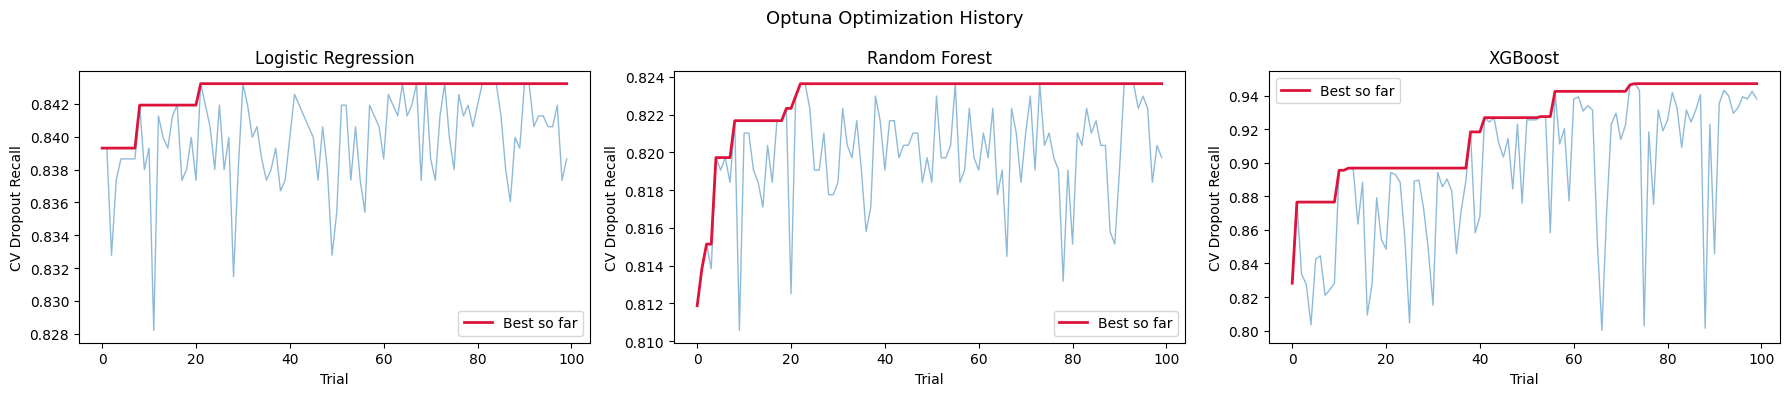


HPO Results Summary:
                              Recall        Precision         F1-macro         Accuracy
Model                                                                                  
Logistic Regression  0.8432 ± 0.0135  0.8218 ± 0.0087  0.8682 ± 0.0077  0.8779 ± 0.0070
Random Forest        0.8236 ± 0.0139  0.8692 ± 0.0106  0.8813 ± 0.0066  0.8920 ± 0.0058
XGBoost              0.9471 ± 0.0091  0.5727 ± 0.0138  0.7261 ± 0.0139  0.7268 ± 0.0142


In [13]:
# ── 4. HPO Pipeline (Optuna) ──────────────────────────────────────────────────
# TPE sampler with 100 trials per model; 5-fold stratified CV with SMOTE inside
# each fold to prevent leakage. Objective = mean Dropout recall (pos_label=1).

N_TRIALS   = 100
N_CV_FOLDS = 5

cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'recall':    make_scorer(recall_score,    pos_label=1),
    'precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'f1_macro':  make_scorer(f1_score,        average='macro'),
    'accuracy':  make_scorer(accuracy_score),
}

# ── 4a. Per-model objective factories ────────────────────────────────────────

def make_objective(model_name, X, y):
    """Return an Optuna objective function for the given model family."""

    def objective(trial):
        if model_name == 'Logistic Regression':
            clf = LogisticRegression(
                C            = trial.suggest_float('C', 1e-3, 100, log=True),
                solver       = trial.suggest_categorical('solver', ['lbfgs', 'liblinear']),
                class_weight = trial.suggest_categorical('class_weight', ['balanced', None]),
                max_iter     = 1000,
                random_state = RANDOM_STATE,
            )

        elif model_name == 'Random Forest':
            clf = RandomForestClassifier(
                n_estimators      = trial.suggest_int('n_estimators', 100, 500),
                max_depth         = trial.suggest_categorical('max_depth', [None, 5, 10, 20]),
                min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
                class_weight      = trial.suggest_categorical('class_weight', ['balanced', None]),
                random_state      = RANDOM_STATE,
            )

        else:  # XGBoost
            clf = XGBClassifier(
                n_estimators      = trial.suggest_int('n_estimators', 100, 500),
                learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                max_depth         = trial.suggest_int('max_depth', 3, 10),
                subsample         = trial.suggest_categorical('subsample', [0.6, 0.7, 0.8, 0.9, 1.0]),
                colsample_bytree  = trial.suggest_categorical('colsample_bytree', [0.6, 0.7, 0.8, 0.9, 1.0]),
                scale_pos_weight  = trial.suggest_categorical('scale_pos_weight', [1, 2, 3, 5]),
                eval_metric       = 'logloss',
                random_state      = RANDOM_STATE,
            )

        pipeline = Pipeline([
            ('smote', SMOTE(random_state=RANDOM_STATE)),
            ('clf',   clf),
        ])

        # cross_validate returns per-fold scores; mean recall is the objective
        cv_scores = cross_validate(
            pipeline, X, y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False,
        )
        return cv_scores['test_recall'].mean()

    return objective


# ── 4b. Run one Optuna study per model ───────────────────────────────────────
hpo_results  = {}
best_studies = {}

for model_name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    print(f'\n── {model_name} ──────────────────────────────────────────────')

    pruner  = MedianPruner(n_startup_trials=10) if model_name == 'XGBoost' else optuna.pruners.NopPruner()
    sampler = TPESampler(seed=RANDOM_STATE)

    study = optuna.create_study(
        direction = 'maximize',
        sampler   = sampler,
        pruner    = pruner,
    )
    study.optimize(
        make_objective(model_name, X_train_aug, y_train_aug),
        n_trials  = N_TRIALS,
        show_progress_bar = True,
    )

    best_params = study.best_params
    best_trial  = study.best_trial
    print(f'  Best params  : {best_params}')
    print(f'  Best recall  : {best_trial.value:.4f}')

    # ── Rebuild best pipeline and re-run CV to collect all metrics ────────────
    if model_name == 'Logistic Regression':
        best_clf = LogisticRegression(
            C            = best_params['C'],
            solver       = best_params['solver'],
            class_weight = best_params['class_weight'],
            max_iter     = 1000,
            random_state = RANDOM_STATE,
        )
    elif model_name == 'Random Forest':
        best_clf = RandomForestClassifier(
            n_estimators      = best_params['n_estimators'],
            max_depth         = best_params['max_depth'],
            min_samples_split = best_params['min_samples_split'],
            class_weight      = best_params['class_weight'],
            random_state      = RANDOM_STATE,
        )
    else:
        best_clf = XGBClassifier(
            n_estimators     = best_params['n_estimators'],
            learning_rate    = best_params['learning_rate'],
            max_depth        = best_params['max_depth'],
            subsample        = best_params['subsample'],
            colsample_bytree = best_params['colsample_bytree'],
            scale_pos_weight = best_params['scale_pos_weight'],
            eval_metric      = 'logloss',
            random_state     = RANDOM_STATE,
        )

    best_pipeline = Pipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf',   best_clf),
    ])

    cv_scores = cross_validate(
        best_pipeline, X_train_aug, y_train_aug,
        cv=cv, scoring=scoring, n_jobs=-1,
    )

    mean_recall    = cv_scores['test_recall'].mean()
    std_recall     = cv_scores['test_recall'].std()
    mean_precision = cv_scores['test_precision'].mean()
    std_precision  = cv_scores['test_precision'].std()
    mean_f1_macro  = cv_scores['test_f1_macro'].mean()
    std_f1_macro   = cv_scores['test_f1_macro'].std()
    mean_accuracy  = cv_scores['test_accuracy'].mean()
    std_accuracy   = cv_scores['test_accuracy'].std()

    # Fit the best pipeline on the full augmented set for downstream use
    best_pipeline.fit(X_train_aug, y_train_aug)

    hpo_results[model_name] = {
        'best_estimator':    best_pipeline,
        'best_recall_cv':    best_trial.value,
        'mean_recall_cv':    mean_recall,
        'std_recall_cv':     std_recall,
        'mean_precision_cv': mean_precision,
        'std_precision_cv':  std_precision,
        'mean_f1_macro_cv':  mean_f1_macro,
        'std_f1_macro_cv':   std_f1_macro,
        'mean_accuracy_cv':  mean_accuracy,
        'std_accuracy_cv':   std_accuracy,
    }
    best_studies[model_name] = study

    print(f'  Recall       : {mean_recall:.4f} ± {std_recall:.4f}')
    print(f'  Precision    : {mean_precision:.4f} ± {std_precision:.4f}')
    print(f'  F1-macro     : {mean_f1_macro:.4f} ± {std_f1_macro:.4f}')
    print(f'  Accuracy     : {mean_accuracy:.4f} ± {std_accuracy:.4f}')

print('\n── HPO complete ─────────────────────────────────────────────────────')

# ── 4c. Select best model ─────────────────────────────────────────────────────
best_model_name = max(hpo_results, key=lambda k: hpo_results[k]['mean_recall_cv'])
best_estimator  = hpo_results[best_model_name]['best_estimator']
print(f'\nBest model: {best_model_name}  '
      f'(mean CV recall = {hpo_results[best_model_name]["mean_recall_cv"]:.4f})')

# ── 4d. Optuna optimization history plot ─────────────────────────────────────
fig, axes = plt.subplots(1, len(best_studies), figsize=(6 * len(best_studies), 4))
if len(best_studies) == 1:
    axes = [axes]
for ax, (name, study) in zip(axes, best_studies.items()):
    trials_df = study.trials_dataframe()
    ax.plot(trials_df['number'], trials_df['value'], alpha=0.5, linewidth=1)
    ax.plot(
        trials_df['number'],
        trials_df['value'].cummax(),
        color='crimson', linewidth=2, label='Best so far'
    )
    ax.set_title(name)
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV Dropout Recall')
    ax.legend()
plt.suptitle('Optuna Optimization History', fontsize=13)
plt.tight_layout()
plt.show()

# ── 4e. Display HPO results table ────────────────────────────────────────────
rows = []
for name, res in hpo_results.items():
    rows.append({
        'Model':     name,
        'Recall':    f"{res['mean_recall_cv']:.4f} ± {res['std_recall_cv']:.4f}",
        'Precision': f"{res['mean_precision_cv']:.4f} ± {res['std_precision_cv']:.4f}",
        'F1-macro':  f"{res['mean_f1_macro_cv']:.4f} ± {res['std_f1_macro_cv']:.4f}",
        'Accuracy':  f"{res['mean_accuracy_cv']:.4f} ± {res['std_accuracy_cv']:.4f}",
    })

results_df = pd.DataFrame(rows).set_index('Model')
print('\nHPO Results Summary:')
print(results_df.to_string())

## 5. Threshold Optimization

The best model's decision threshold is scanned from 0.1 to 0.9 (step 0.01) on a held-out 20% validation split. The threshold that achieves Dropout recall ≥ 0.90 with the highest precision is selected. If no threshold reaches 0.90, the maximum-recall threshold is used and a warning is logged.

Validation split shape : (852, 39)
Class distribution (val):
Graduate (0)    546
Dropout (1)     306

Threshold scan complete: 81 thresholds evaluated.

Optimal threshold : 0.67
Recall            : 0.9052
Precision         : 0.8006
F1                : 0.8497


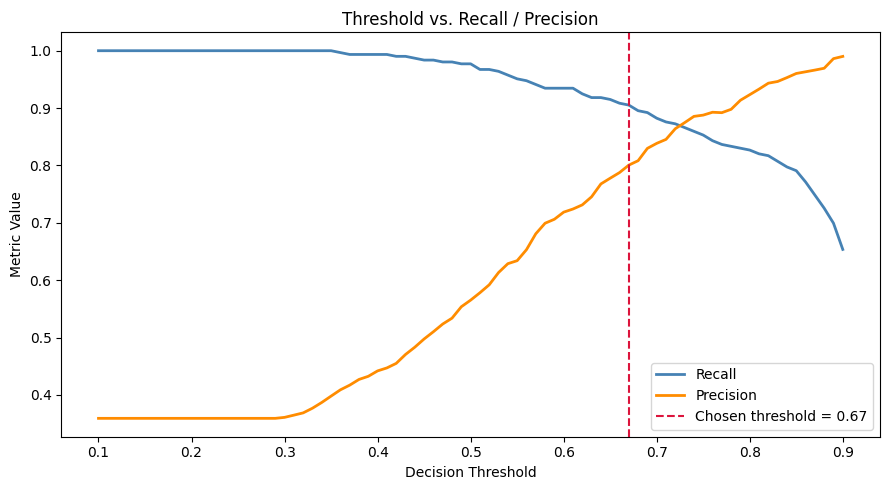


Chosen threshold  : 0.67
Recall            : 0.9052
Precision         : 0.8006
F1                : 0.8497


In [14]:
# ── 5. Threshold Optimization ─────────────────────────────────────────────────
# Task 6.1: Scan thresholds 0.1–0.9 on a held-out 20% validation split
# Task 6.4: Plot recall and precision vs. threshold

# ── 5a. Create 20% stratified validation split ────────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_aug, y_train_aug,
    test_size=0.2,
    stratify=y_train_aug,
    random_state=RANDOM_STATE,
)

print(f'Validation split shape : {X_val.shape}')
print('Class distribution (val):')
print(y_val.value_counts().rename({0: 'Graduate (0)', 1: 'Dropout (1)'}).to_string())

# ── 5b. Get predicted probabilities from best estimator ───────────────────────
y_proba_val = best_estimator.predict_proba(X_val)
# y_proba_val[:, 1] = P(Dropout)

# ── 5c. Scan thresholds and compute recall / precision ────────────────────────
thresholds = np.arange(0.1, 0.91, 0.01)
threshold_results = {}

for t in thresholds:
    t = round(t, 2)  # avoid floating-point key drift
    y_pred_t = (y_proba_val[:, 1] >= t).astype(int)
    r = recall_score(y_val, y_pred_t, pos_label=1)
    p = precision_score(y_val, y_pred_t, pos_label=1, zero_division=0)
    threshold_results[t] = {'recall': r, 'precision': p}

print(f'\nThreshold scan complete: {len(threshold_results)} thresholds evaluated.')

# ── 5d. Selection logic ───────────────────────────────────────────────────────
qualifying = {
    t: v for t, v in threshold_results.items() if v['recall'] >= 0.90
}

if qualifying:
    # Pick highest precision among thresholds that achieve recall >= 0.90
    optimal_threshold = max(qualifying, key=lambda t: qualifying[t]['precision'])
else:
    # No threshold reaches 0.90 — pick the one with maximum recall
    optimal_threshold = max(threshold_results, key=lambda t: threshold_results[t]['recall'])
    threshold_recall = threshold_results[optimal_threshold]['recall']
    import warnings as _w
    _w.warn(
        f'No threshold achieves recall >= 0.90. '
        f'Best achievable recall: {threshold_recall:.4f}, '
        f'shortfall: {0.90 - threshold_recall:.4f}'
    )

threshold_recall    = threshold_results[optimal_threshold]['recall']
threshold_precision = threshold_results[optimal_threshold]['precision']
threshold_f1 = (
    2 * threshold_precision * threshold_recall
    / (threshold_precision + threshold_recall + 1e-9)
)

print(f'\nOptimal threshold : {optimal_threshold:.2f}')
print(f'Recall            : {threshold_recall:.4f}')
print(f'Precision         : {threshold_precision:.4f}')
print(f'F1                : {threshold_f1:.4f}')

# ── 5e. Plot threshold vs. recall / precision (Task 6.4) ─────────────────────
t_vals  = sorted(threshold_results.keys())
recalls    = [threshold_results[t]['recall']    for t in t_vals]
precisions = [threshold_results[t]['precision'] for t in t_vals]

plt.figure(figsize=(9, 5))
plt.plot(t_vals, recalls,    label='Recall',    color='steelblue',  linewidth=2)
plt.plot(t_vals, precisions, label='Precision', color='darkorange', linewidth=2)
plt.axvline(
    x=optimal_threshold,
    color='crimson',
    linestyle='--',
    linewidth=1.5,
    label=f'Chosen threshold = {optimal_threshold:.2f}',
)
plt.title('Threshold vs. Recall / Precision')
plt.xlabel('Decision Threshold')
plt.ylabel('Metric Value')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nChosen threshold  : {optimal_threshold:.2f}')
print(f'Recall            : {threshold_recall:.4f}')
print(f'Precision         : {threshold_precision:.4f}')
print(f'F1                : {threshold_f1:.4f}')

## 6. Final Training & Export

The best model configuration is retrained on the full augmented dataset (hard-labeled + pseudo-labeled Enrolled students). The model and metadata are exported to `../models/`.

In [15]:
# ── 6. Final Training & Export ────────────────────────────────────────────────
# Task 8.1: Retrain best model on full augmented dataset
# Task 8.2: Save model metadata
# Task 8.3: Verify serialization round-trip
# Task 8.6: Print final summary table

from sklearn.base import clone

# ── 8.1 Retrain on full augmented dataset ─────────────────────────────────────
print('Retraining best model on full augmented dataset...')
final_model = clone(best_estimator)
final_model.fit(X_train_aug, y_train_aug)
print(f'Final model trained: {best_model_name}')

os.makedirs('../models', exist_ok=True)
joblib.dump(final_model, '../models/xgboost_dropout_model.pkl')
joblib.dump(final_model, '../models/best_model.pkl')
print('Saved: ../models/xgboost_dropout_model.pkl')
print('Saved: ../models/best_model.pkl')

# ── 8.2 Save model metadata ───────────────────────────────────────────────────
metadata = {
    'threshold':            optimal_threshold,
    'model_name':           best_model_name,
    'dropout_recall_cv':    hpo_results[best_model_name]['mean_recall_cv'],
    'dropout_precision_cv': hpo_results[best_model_name]['mean_precision_cv'],
    'feature_names':        X_train_aug.columns.tolist(),
}
joblib.dump(metadata, '../models/model_metadata.pkl')
print('Saved: ../models/model_metadata.pkl')
print(f'  threshold            : {metadata["threshold"]}')
print(f'  model_name           : {metadata["model_name"]}')
print(f'  dropout_recall_cv    : {metadata["dropout_recall_cv"]:.4f}')
print(f'  dropout_precision_cv : {metadata["dropout_precision_cv"]:.4f}')
print(f'  feature_names        : {len(metadata["feature_names"])} features')

# ── 8.3 Verify serialization round-trip ──────────────────────────────────────
loaded_xgb  = joblib.load('../models/xgboost_dropout_model.pkl')
loaded_best = joblib.load('../models/best_model.pkl')

sample = X_train_aug.iloc[:5]

for label, loaded in [('xgboost_dropout_model', loaded_xgb), ('best_model', loaded_best)]:
    pred_mem   = final_model.predict(sample)
    pred_disk  = loaded.predict(sample)
    proba_mem  = final_model.predict_proba(sample)
    proba_disk = loaded.predict_proba(sample)

    if not np.array_equal(pred_mem, pred_disk):
        raise AssertionError(
            f'predict mismatch for {label}:\n'
            f'  in-memory : {pred_mem}\n'
            f'  from disk : {pred_disk}'
        )
    if not np.allclose(proba_mem, proba_disk):
        raise AssertionError(
            f'predict_proba mismatch for {label}:\n'
            f'  in-memory : {proba_mem}\n'
            f'  from disk : {proba_disk}'
        )

print('Serialization round-trip verified.')

# ── 8.6 Final summary table ───────────────────────────────────────────────────
summary_rows = []
for name, res in hpo_results.items():
    chosen_threshold = optimal_threshold if name == best_model_name else '-'
    expected_recall  = (
        f'{threshold_recall:.4f}'
        if name == best_model_name
        else '-'
    )
    summary_rows.append({
        'Model':                    name,
        'CV Dropout Recall':        f"{res['mean_recall_cv']:.4f} ± {res['std_recall_cv']:.4f}",
        'Chosen Threshold':         chosen_threshold,
        'Expected Dropout Recall':  expected_recall,
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('\n── Final Summary ────────────────────────────────────────────────────')
print(summary_df.to_string())

Retraining best model on full augmented dataset...
Final model trained: XGBoost
Saved: ../models/xgboost_dropout_model.pkl
Saved: ../models/best_model.pkl
Saved: ../models/model_metadata.pkl
  threshold            : 0.67
  model_name           : XGBoost
  dropout_recall_cv    : 0.9471
  dropout_precision_cv : 0.5727
  feature_names        : 39 features
Serialization round-trip verified.

── Final Summary ────────────────────────────────────────────────────
                    CV Dropout Recall Chosen Threshold Expected Dropout Recall
Model                                                                         
Logistic Regression   0.8432 ± 0.0135                -                       -
Random Forest         0.8236 ± 0.0139                -                       -
XGBoost               0.9471 ± 0.0091             0.67                  0.9052
